In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
#creating views
con = duckdb.connect()

con.execute("CREATE VIEW orders AS SELECT * FROM 'Orders.csv'")
con.execute("CREATE VIEW products AS SELECT * FROM 'Products.csv'")
con.execute("CREATE VIEW customers AS SELECT * FROM 'Customers.csv'")
con.execute("CREATE VIEW Order_Items AS SELECT * FROM 'Order_Items.csv'")
con.execute("CREATE VIEW Returns AS SELECT * FROM 'Returns.csv'")
con.execute("CREATE VIEW Reviews AS SELECT * FROM 'Reviews.csv'")

orders = con.execute("SELECT * FROM orders").df()
products = con.execute("SELECT * FROM products").df()
customers = con.execute("SELECT * FROM customers").df()
order_items = con.execute("SELECT * FROM order_items").df()
returns = con.execute("SELECT * FROM returns").df()
reviews = con.execute("SELECT * FROM reviews").df()

In [3]:
orders

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date
0,O00001,C0047,2024-06-10,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,2024-06-14
1,O00002,C0016,2025-02-18,Delivered,Credit Card,Website,349.00,0.00,40,389.00,2025-02-21
2,O00003,C0191,2025-12-03,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,2025-12-09
3,O00004,C0087,2025-08-10,Delivered,Credit Card,Website,663.10,34.90,49,712.10,2025-08-17
4,O00005,C0211,2025-07-17,Delivered,UPI,Website,1511.35,134.65,0,1511.35,2025-07-23
...,...,...,...,...,...,...,...,...,...,...,...
1245,O01246,C0165,2025-04-07,Delivered,Credit Card,Mobile App,598.00,0.00,49,647.00,2025-04-13
1246,O01247,C0457,2024-01-13,Delivered,UPI,Website,1423.90,172.10,0,1423.90,2024-01-19
1247,O01248,C0284,2025-02-12,Delivered,COD,Mobile App,948.00,0.00,0,948.00,2025-02-19
1248,O01249,C0444,2024-07-27,Delivered,UPI,Website,2070.70,324.30,0,2070.70,2024-08-01


In [4]:
reviews

,review_id,customer_id,product_id,order_id,rating,review_date
0,RV00001,C0047,P023,O00001,4,2024-06-19
1,RV00002,C0191,P001,O00003,5,2025-12-08
2,RV00003,C0087,P009,O00004,5,2025-08-29
3,RV00004,C0289,P007,O00009,1,2024-06-17
4,RV00005,C0476,P016,O00012,3,2025-10-04
...,...,...,...,...,...,...
489,RV00490,C0086,P014,O01245,5,2025-07-12
490,RV00491,C0165,P016,O01246,1,2025-04-18
491,RV00492,C0457,P026,O01247,5,2024-02-03
492,RV00493,C0284,P001,O01248,5,2025-02-22


In [5]:
#creating mart for rfm clusters
rfm = con.execute("""
    SELECT
        customer_id,
        
        -- Recency: дней с последнего заказа
        DATEDIFF('day', MAX(order_date::DATE), DATE '2025-12-31') AS recency,
        
        -- Frequency: количество заказов
        COUNT(order_id) AS frequency,
        
        -- Monetary: суммарная выручка
        ROUND(SUM(final_amount), 2) AS monetary

    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id

""").df()

print(rfm.shape)
rfm.head(10)

(438, 4)


,customer_id,recency,frequency,monetary
0,C0401,14,4,3963.15
1,C0472,104,3,2843.50
2,C0334,27,1,618.05
3,C0374,177,4,3493.40
4,C0089,4,2,1341.45
5,C0232,0,3,2699.95
6,C0409,18,2,2801.15
7,C0359,216,3,2232.75
8,C0470,245,6,8251.55
9,C0266,337,4,2120.00


In [6]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

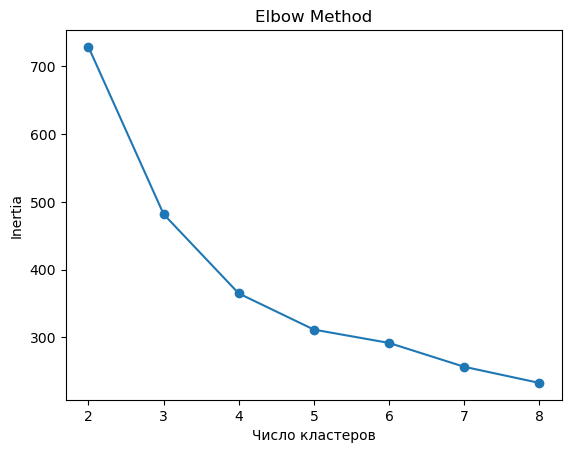

In [7]:
#using Elbow method to find optimal number of clusters
from sklearn.cluster import KMeans

inertia = []
K = range(2, 9)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
#k = 4 is optimal

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# average values of clusters
rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(1)

,recency,frequency,monetary
cluster,,,
0,125.3,1.5,1137.3
1,501.9,1.4,1157.2
2,147.2,4.6,4862.3
3,196.5,2.8,2864.8


In [9]:
segment_map = {
    0: 'Lost',
    1: 'Risk',
    2: 'New',      
    3: 'VIP'         
}

rfm['segment'] = rfm['cluster'].map(segment_map)
rfm.to_csv('rfm_segments.csv', index=False)

In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['cluster'])
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.373


In [11]:
#Silhouette score 0.373 is fine for synthetic data

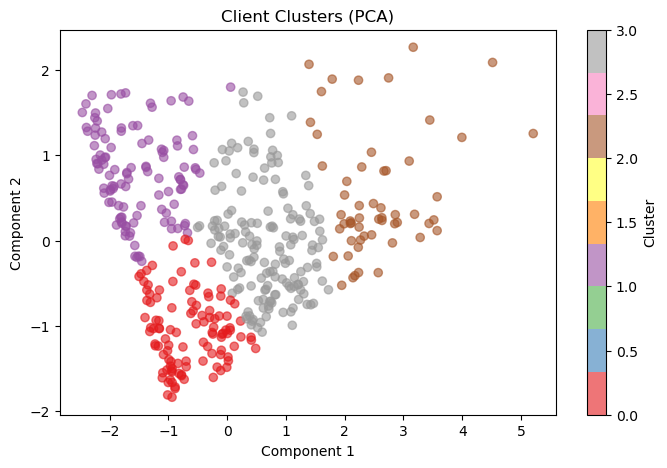

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
components = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(components[:, 0], components[:, 1], 
                      c=rfm['cluster'], cmap='Set1', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Client Clusters (PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

In [13]:
#creating mart for clv
con = duckdb.connect()
con.execute("CREATE VIEW orders AS SELECT * FROM 'Orders.csv'")

clv_data = con.execute("""
    SELECT
        customer_id,
        COUNT(order_id) - 1 AS frequency,
        DATEDIFF('day', MIN(order_date::DATE), MAX(order_date::DATE)) AS recency,
        DATEDIFF('day', MIN(order_date::DATE), DATE '2025-12-31') AS T,
        ROUND(AVG(final_amount), 2) AS monetary_value
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
    HAVING COUNT(order_id) >= 1
""").df()

print(clv_data.shape)
clv_data.head()

(438, 5)


,customer_id,frequency,recency,T,monetary_value
0,C0067,7,567,643,824.35
1,C0080,4,503,726,721.69
2,C0408,3,438,610,1498.24
3,C0335,0,0,578,390.55
4,C0187,1,153,320,736.05


In [14]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    clv_data['frequency'],
    clv_data['recency'],
    clv_data['T']
)

print(bgf.summary)

             coef    se(coef)  lower 95% bound  upper 95% bound
r        1.797921    0.185588         1.434168         2.161674
alpha  605.531525  100.636087       408.284795       802.778254
a        0.021257    0.081025        -0.137553         0.180067
b        0.377362    0.616763        -0.831494         1.586218


In [15]:
from lifetimes import GammaGammaFitter

# Only clients with frequency > 0
repeat_customers = clv_data[clv_data['frequency'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    repeat_customers['frequency'],
    repeat_customers['monetary_value']
)

print(ggf.summary)

       coef  se(coef)  lower 95% bound  upper 95% bound
p  3.490979  0.299119         2.904706         4.077253
q  0.239680  0.015293         0.209705         0.269654
v  3.356089  0.304249         2.759761         3.952418


In [16]:
#predict clv for 12 months
clv_data['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    clv_data['frequency'],
    clv_data['recency'],
    clv_data['T'],
    clv_data['monetary_value'],
    time=12,        
    freq='D',       
    discount_rate=0.01
)

clv_data = clv_data.round(2)
clv_data.sort_values('predicted_clv', ascending=False).head(10)

,customer_id,frequency,recency,T,monetary_value,predicted_clv
189,C0161,1,111,114,2244.32,3530.92
232,C0386,2,8,179,1877.92,3292.05
325,C0470,5,230,475,1375.26,2960.02
130,C0490,4,583,716,1532.01,2364.60
323,C0409,1,68,86,1400.58,2286.09
198,C0269,4,416,631,1364.63,2234.29
213,C0069,4,252,632,1404.70,2224.35
93,C0103,3,272,499,1446.45,2218.13
333,C0434,3,198,341,1218.58,2195.08
113,C0328,1,387,502,2106.55,2120.98


In [17]:
print(bgf.summary)

             coef    se(coef)  lower 95% bound  upper 95% bound
r        1.797921    0.185588         1.434168         2.161674
alpha  605.531525  100.636087       408.284795       802.778254
a        0.021257    0.081025        -0.137553         0.180067
b        0.377362    0.616763        -0.831494         1.586218


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

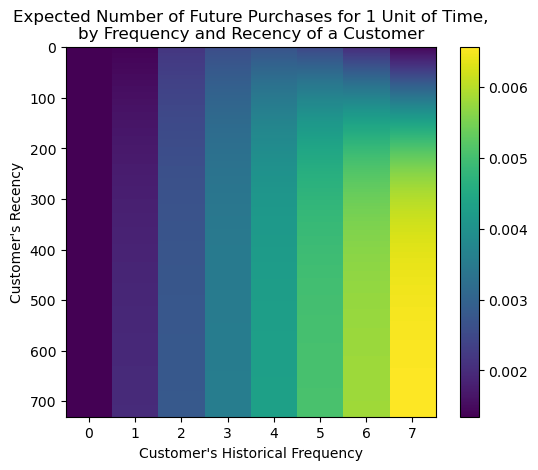

In [18]:
from lifetimes.plotting import plot_frequency_recency_matrix

plot_frequency_recency_matrix(bgf)

In [19]:
# Hold-out validation
from lifetimes.utils import calibration_and_holdout_data
delivered_orders = con.execute("""
    SELECT * FROM Orders
    WHERE order_status = 'Delivered'
""").df()
summary = calibration_and_holdout_data(
    delivered_orders,           
    customer_id_col='customer_id',
    datetime_col='order_date',
    calibration_period_end='2025-06-30',  
    observation_period_end='2025-12-31'   
)

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

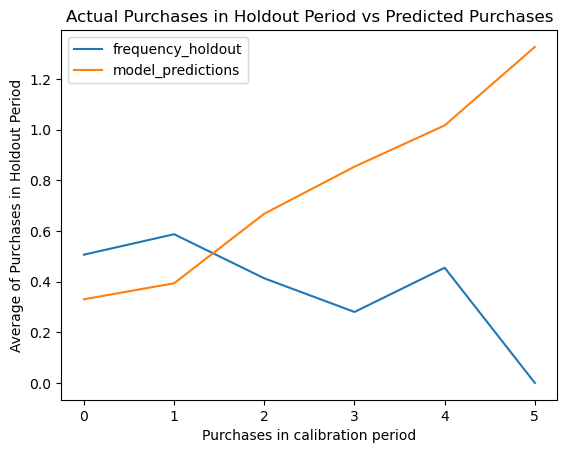

In [20]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

bgf.fit(summary['frequency_cal'], summary['recency_cal'], summary['T_cal'])
plot_calibration_purchases_vs_holdout_purchases(bgf, summary)

In [21]:
#Difference between actual purchases and predicted purchases is severe due to limitations of synthetic data

In [22]:
#Churn
churn_data = con.execute("""
    SELECT
        o.customer_id,
        COUNT(o.order_id) AS frequency,
        ROUND(SUM(o.final_amount), 2) AS monetary,
        ROUND(AVG(o.final_amount), 2) AS avg_order_value,
        DATEDIFF('day', MAX(o.order_date::DATE), DATE '2025-12-31') AS recency,
        DATEDIFF('day', MIN(o.order_date::DATE), MAX(o.order_date::DATE)) AS customer_age,
        COUNT(DISTINCT o.payment_method) AS payment_methods_used,
        COUNT(DISTINCT o.sales_channel) AS channels_used
    FROM orders o
    WHERE o.order_status = 'Delivered'
    GROUP BY o.customer_id
""").df()


churn_data['churn'] = (churn_data['recency'] > 120).astype(int)

print('Churn distribution:')
print(churn_data['churn'].value_counts())
print()
churn_data.head()

Churn distribution:
churn
1    297
0    141
Name: count, dtype: int64



,customer_id,frequency,monetary,avg_order_value,recency,customer_age,payment_methods_used,channels_used,churn
0,C0255,3,2189.55,729.85,109,621,2,1,0
1,C0299,4,4755.55,1188.89,119,328,3,2,0
2,C0457,3,2740.40,913.47,424,294,3,2,1
3,C0286,3,2239.80,746.60,236,422,2,2,1
4,C0346,2,1072.10,536.05,126,114,1,2,1


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils import resample

features = ['frequency', 'monetary', 'avg_order_value', 
            'customer_age', 'payment_methods_used', 'channels_used']

X = churn_data[features]
y = churn_data['churn']

# Balancing classes using upsampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# class_weight='balanced'
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}')

              precision    recall  f1-score   support

           0       0.50      0.46      0.48        28
           1       0.76      0.78      0.77        60

    accuracy                           0.68        88
   macro avg       0.63      0.62      0.63        88
weighted avg       0.68      0.68      0.68        88

AUC-ROC: 0.698


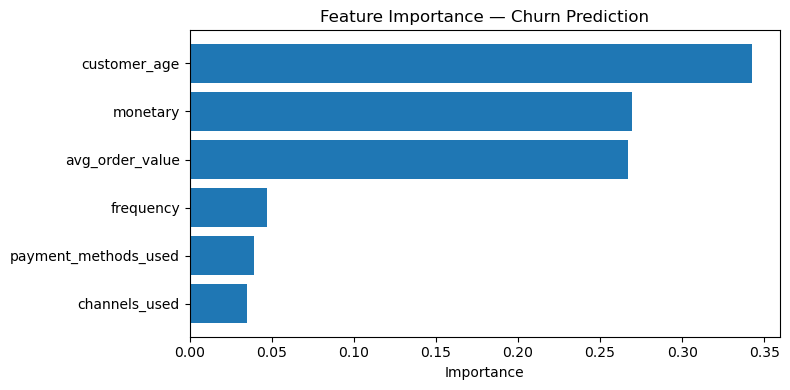

In [24]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance — Churn Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [25]:
churn_data['churn_probability'] = model.predict_proba(X)[:, 1].round(3)

churn_export = churn_data[['customer_id', 'churn', 'churn_probability']]
churn_export.to_csv('churn_results.csv', index=False)